# Inspect Trained MLP Surrogate

This notebook checks that the trained MLP workflow works end-to-end.

The MLP acts only in normalized PCA space:

$$
\mathcal{N}_{\theta}: \tilde{a} \longmapsto \tilde{u}.
$$

The full surrogate is the operator

$$
\mathcal{S}_{\theta}: a \longmapsto \hat{y},
$$

where the complete workflow is

$$
a
\longmapsto
\tilde{a}
=
\frac{a-\mu_A}{\sigma_A}
\longmapsto
\hat{\tilde{u}}
=
\mathcal{N}_{\theta}(\tilde{a})
\longmapsto
\hat{u}
=
\mu_U + \sigma_U \odot \hat{\tilde{u}}
\longmapsto
\hat{y}
=
\bar{y} + \hat{u}\Phi.
$$

Equivalently,

$$
\boxed{
\mathcal{S}_{\theta}(a)
=
\bar{y}
+
\left[
\mu_U
+
\sigma_U \odot
\mathcal{N}_{\theta}
\left(
\frac{a-\mu_A}{\sigma_A}
\right)
\right]\Phi
}
$$

This notebook checks:

1. the saved model and scaler files load correctly,
2. the MLP predicts PCA coefficients with reasonable error,
3. the full surrogate reconstructs reasonable SCR output signals,
4. random test samples visually compare well against their PCA-reconstructed targets.

## 1. Imports and Paths

This step imports the required libraries, defines paths to the saved split dataset and trained MLP files, and loads the surrogate helper from `mlp_surrogate.py`.

In [16]:
from pathlib import Path
import sys
import json
import importlib

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# Current notebook is in ~/AME508/3_ML
ROOT = Path.cwd().parent

FULL_DATASET_PATH = ROOT / "1_DATA" / "Full_Dataset.npy"
PCA_DIR = ROOT / "2_PCA"
ML_DIR = ROOT / "3_ML"

SPLIT_DATASET_PATH = PCA_DIR / "PCA_Dataset_r20_split.npz"

MODEL_PATH = ML_DIR / "mlp_Anorm_to_Unorm_r20.pt"
SCALER_PATH = ML_DIR / "mlp_Anorm_to_Unorm_r20_scalers.npz"
HISTORY_PATH = ML_DIR / "mlp_Anorm_to_Unorm_r20_history.json"
CONFIG_PATH = ML_DIR / "mlp_Anorm_to_Unorm_r20_config.json"

sys.path.append(str(ML_DIR))

import mlp_surrogate
importlib.reload(mlp_surrogate)

from mlp_surrogate import MLPSurrogate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("cwd:                 ", Path.cwd())
print("ROOT:                ", ROOT)
print("PCA_DIR:             ", PCA_DIR)
print("ML_DIR:              ", ML_DIR)
print()
print("Full dataset exists: ", FULL_DATASET_PATH.exists(), FULL_DATASET_PATH)
print("Split dataset exists:", SPLIT_DATASET_PATH.exists(), SPLIT_DATASET_PATH)
print("Model exists:        ", MODEL_PATH.exists(), MODEL_PATH)
print("Scaler exists:       ", SCALER_PATH.exists(), SCALER_PATH)
print("History exists:      ", HISTORY_PATH.exists(), HISTORY_PATH)
print("Config exists:       ", CONFIG_PATH.exists(), CONFIG_PATH)
print()
print("Torch version:", torch.__version__)
print("Device:       ", device)

assert FULL_DATASET_PATH.exists()
assert SPLIT_DATASET_PATH.exists()
assert MODEL_PATH.exists()
assert SCALER_PATH.exists()
assert CONFIG_PATH.exists()

cwd:                  /home/ssariedd/AME508/2_PCA
ROOT:                 /home/ssariedd/AME508
PCA_DIR:              /home/ssariedd/AME508/2_PCA
ML_DIR:               /home/ssariedd/AME508/3_ML

Full dataset exists:  True /home/ssariedd/AME508/1_DATA/Full_Dataset.npy
Split dataset exists: True /home/ssariedd/AME508/2_PCA/PCA_Dataset_r20_split.npz
Model exists:         True /home/ssariedd/AME508/3_ML/mlp_Anorm_to_Unorm_r20.pt
Scaler exists:        True /home/ssariedd/AME508/3_ML/mlp_Anorm_to_Unorm_r20_scalers.npz
History exists:       True /home/ssariedd/AME508/3_ML/mlp_Anorm_to_Unorm_r20_history.json
Config exists:        True /home/ssariedd/AME508/3_ML/mlp_Anorm_to_Unorm_r20_config.json

Torch version: 2.5.1
Device:        cpu


## 2. Load Split Dataset

This step loads the train / validation / test split and PCA reconstruction data.

In [6]:
data = np.load(SPLIT_DATASET_PATH)

A_train = data["A_train"]
A_val = data["A_val"]
A_test = data["A_test"]

U_train = data["U_train"]
U_val = data["U_val"]
U_test = data["U_test"]

Phi = data["Phi"]
Y_mean = data["Y_mean"]
t = data["t"]
r = int(data["r"])

print("A_train:", A_train.shape)
print("A_val:  ", A_val.shape)
print("A_test: ", A_test.shape)

print("\nU_train:", U_train.shape)
print("U_val:  ", U_val.shape)
print("U_test: ", U_test.shape)

print("\nPhi:    ", Phi.shape)
print("Y_mean: ", Y_mean.shape)
print("t:      ", t.shape)
print("r:      ", r)

A_train: (4000, 6)
A_val:   (500, 6)
A_test:  (500, 6)

U_train: (4000, 20)
U_val:   (500, 20)
U_test:  (500, 20)

Phi:     (20, 11993)
Y_mean:  (11993,)
t:       (11993,)
r:       20


## 3. Load Surrogate Operator

This step loads the trained MLP weights, normalization scalers, and PCA reconstruction data into the full surrogate operator

$$
\mathcal{S}_{\theta}: a \longmapsto \hat{y}.
$$

In [8]:
surrogate = MLPSurrogate(
    model_path=MODEL_PATH,
    scaler_path=SCALER_PATH,
    pca_dataset_path=SPLIT_DATASET_PATH,
    config_path=CONFIG_PATH,
    device=device,
)

print("Surrogate loaded.")

print("\nPCA data:")
print("r:      ", surrogate.r)
print("Phi:    ", surrogate.Phi.shape)
print("Y_mean: ", surrogate.Y_mean.shape)
print("t:      ", surrogate.t.shape)

print("\nScaler data:")
print("A_mean: ", surrogate.A_mean.shape)
print("A_std:  ", surrogate.A_std.shape)
print("U_mean: ", surrogate.U_mean.shape)
print("U_std:  ", surrogate.U_std.shape)

print("\nMLP:")
print(surrogate.model)

n_params = sum(p.numel() for p in surrogate.model.parameters())
print("\nNumber of trainable parameters:", n_params)

print("\nDevice:", surrogate.device)

Surrogate loaded.

PCA data:
r:       20
Phi:     (20, 11993)
Y_mean:  (11993,)
t:       (11993,)

Scaler data:
A_mean:  (6,)
A_std:   (6,)
U_mean:  (20,)
U_std:   (20,)

MLP:
MLP(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=20, bias=True)
  )
)

Number of trainable parameters: 53012

Device: cpu


## 4. Predict Full SCR Output Signals on the Test Set

This step checks the full workflow:

$$
a
\longmapsto
\tilde{a}
\longmapsto
\mathcal{N}_{\theta}(\tilde{a})
=
\hat{\tilde{u}}
\longmapsto
\hat{u}
\longmapsto
\hat{y}.
$$

The full surrogate is

$$
\mathcal{S}_{\theta}: a \longmapsto \hat{y}.
$$

Therefore,

$$
\boxed{
\mathcal{S}_{\theta}(a)
=
\bar{y}
+
\left[
\mu_U
+
\sigma_U \odot
\mathcal{N}_{\theta}
\left(
\frac{a-\mu_A}{\sigma_A}
\right)
\right]\Phi
}
$$

We compare the surrogate prediction $\hat{y}$ directly against the original full SCR output signal $y$.

The reported errors are computed over all test samples and all time points.

$$
\mathrm{RMSE}
=
\sqrt{
\frac{1}{N_{\mathrm{test}}N_t}
\sum_{m=1}^{N_{\mathrm{test}}}
\sum_{j=1}^{N_t}
\left(
\hat{y}^{(m)}(t_j)
-
y^{(m)}(t_j)
\right)^2
}
$$

$$
\mathrm{Relative\ RMSE}
=
\frac{
\mathrm{RMSE}
}{
\sqrt{
\frac{1}{N_{\mathrm{test}}N_t}
\sum_{m=1}^{N_{\mathrm{test}}}
\sum_{j=1}^{N_t}
\left(
y^{(m)}(t_j)
\right)^2
}
}
$$

$$
\mathrm{MAE}
=
\frac{1}{N_{\mathrm{test}}N_t}
\sum_{m=1}^{N_{\mathrm{test}}}
\sum_{j=1}^{N_t}
\left|
\hat{y}^{(m)}(t_j)
-
y^{(m)}(t_j)
\right|
$$

$$
\mathrm{Max\ Absolute\ Error}
=
\max_{m,j}
\left|
\hat{y}^{(m)}(t_j)
-
y^{(m)}(t_j)
\right|.
$$

In [13]:
# Load original full output dataset
Y = np.load(FULL_DATASET_PATH)

# Make sure Y has shape (N_s, N_t)
if Y.shape[0] != A_train.shape[0] + A_val.shape[0] + A_test.shape[0]:
    if Y.shape[1] == A_train.shape[0] + A_val.shape[0] + A_test.shape[0]:
        Y = Y.T
        print("Transposed Y to:", Y.shape)

print("Y:", Y.shape)

# Recover original test sample indices
idx_test = data["idx_test"]

Y_test = Y[idx_test]

# Full surrogate prediction
Y_test_hat = surrogate.predict_Y(A_test)

y_rmse = np.sqrt(np.mean((Y_test_hat - Y_test)**2))
y_rel_rmse = y_rmse / np.sqrt(np.mean(Y_test**2))
y_mae = np.mean(np.abs(Y_test_hat - Y_test))
y_max_err = np.max(np.abs(Y_test_hat - Y_test))

print("Y_test_hat:", Y_test_hat.shape)
print("Y_test:    ", Y_test.shape)

print("\nFull signal prediction errors:")
print("RMSE:         ", y_rmse)
print("Relative RMSE:", y_rel_rmse)
print("MAE:          ", y_mae)
print("Max abs error:", y_max_err)

Y: (5000, 11993)
Y_test_hat: (500, 11993)
Y_test:     (500, 11993)

Full signal prediction errors:
RMSE:          0.03555942621589719
Relative RMSE: 0.001088332526441859
MAE:           0.022630603991824073
Max abs error: 0.7229120001711893


## 5. Plot Random Test Predictions

This step plots random test samples and compares the true full SCR signal ($y$) against the surrogate prediction ($\hat{y}$).

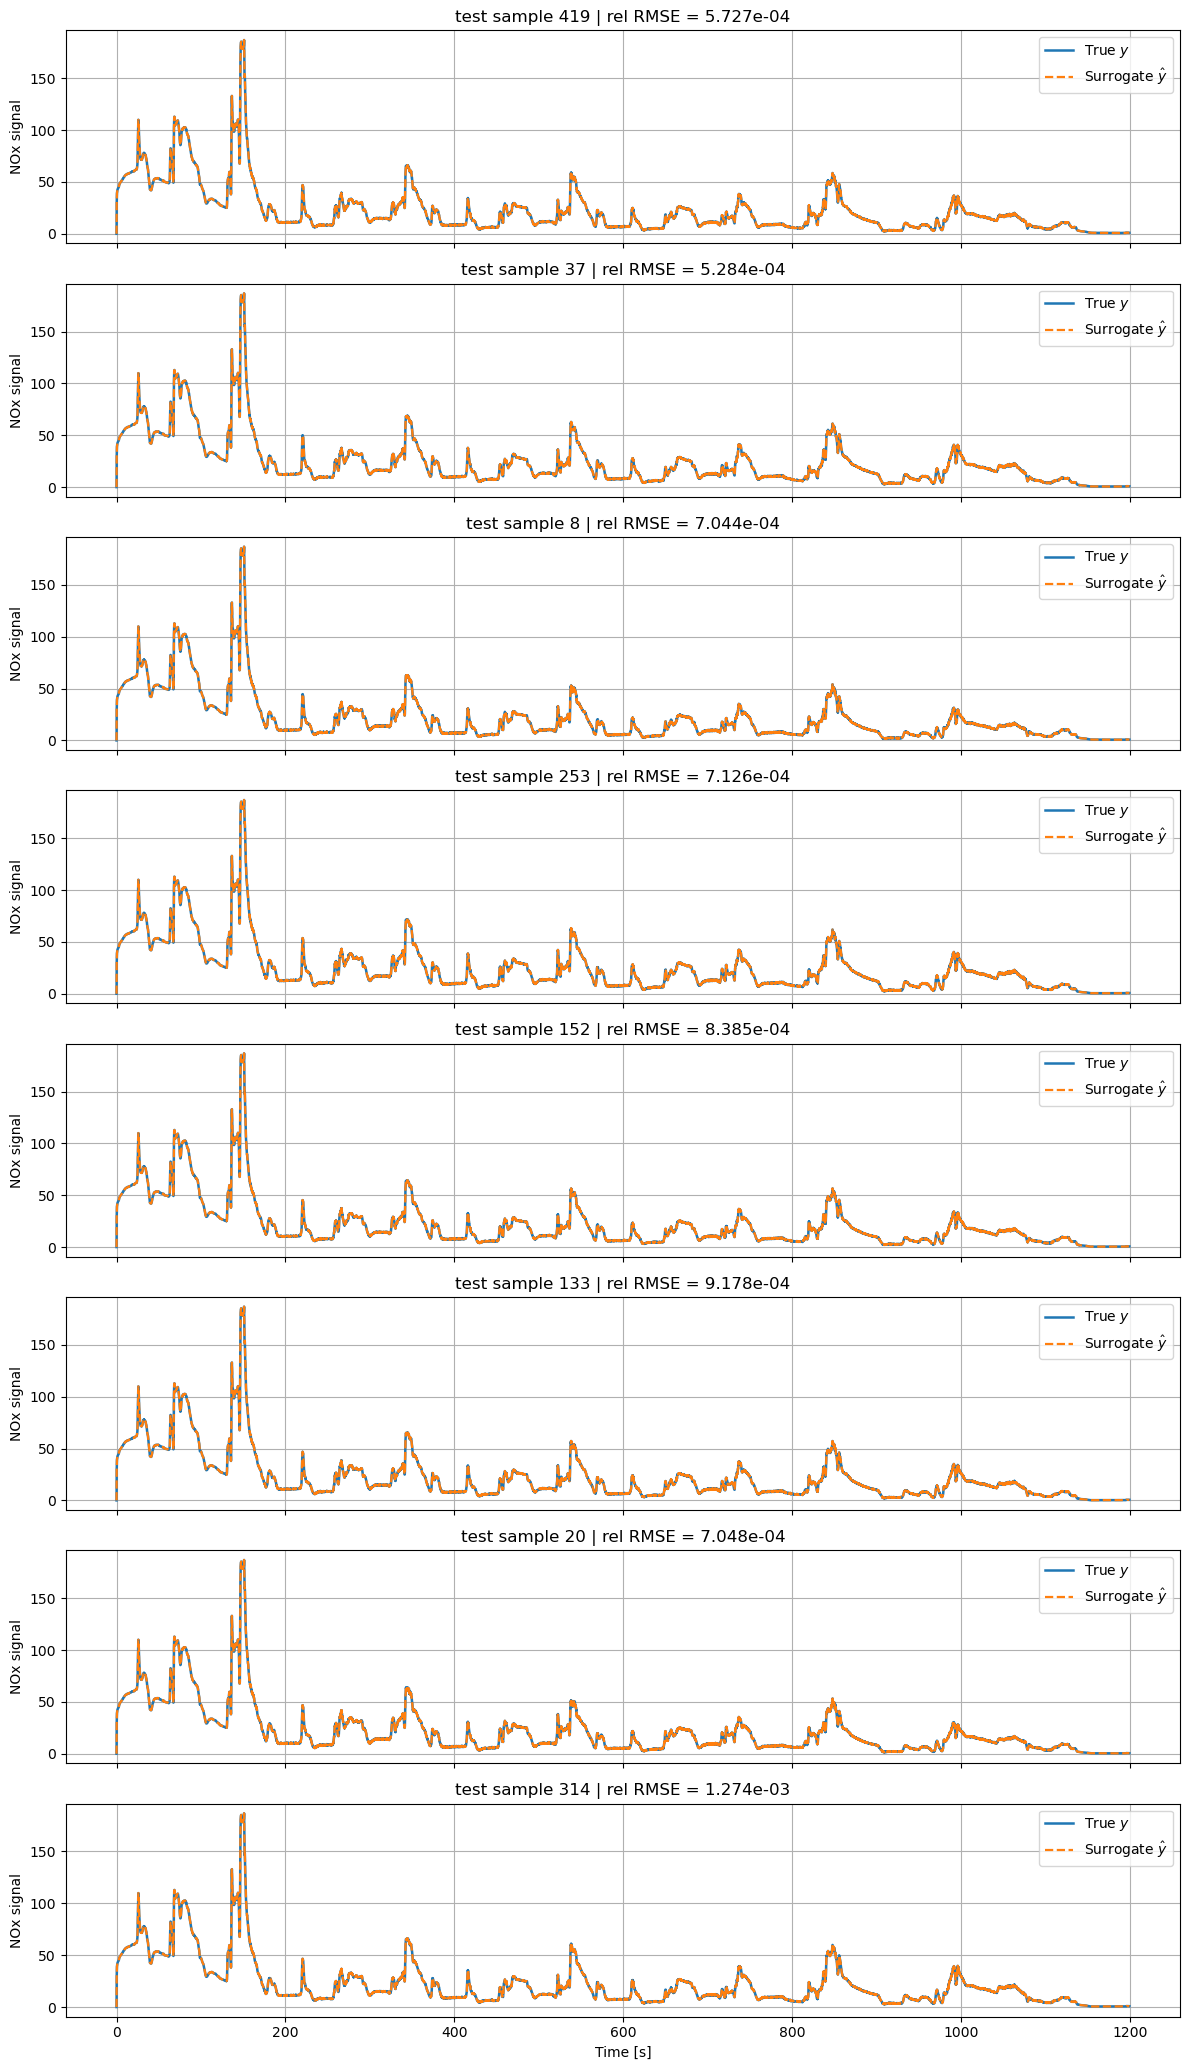

In [15]:
n_plots = 8
seed = 0

rng = np.random.default_rng(seed)
plot_ids = rng.choice(len(A_test), size=n_plots, replace=False)

fig, axes = plt.subplots(
    n_plots,
    1,
    figsize=(12, 2.6 * n_plots),
    sharex=True,
)

if n_plots == 1:
    axes = [axes]

for ax, i in zip(axes, plot_ids):
    ax.plot(t, Y_test[i], label="True $y$", linewidth=1.8)
    ax.plot(t, Y_test_hat[i], "--", label="Surrogate $\\hat{y}$", linewidth=1.6)

    rmse_i = np.sqrt(np.mean((Y_test_hat[i] - Y_test[i])**2))
    rel_i = rmse_i / np.sqrt(np.mean(Y_test[i]**2))

    ax.set_title(f"test sample {i} | rel RMSE = {rel_i:.3e}")
    ax.set_ylabel("NOx signal")
    ax.grid(True)
    ax.legend(loc="best")

axes[-1].set_xlabel("Time [s]")

plt.tight_layout()
plt.show()